     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 8.6 MB/s eta 0:00:00
Loading mujoco/halfcheetah/expert-v0...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


namespace_metadata.json: 0.00B [00:00, ?B/s]

metadata.json: 0.00B [00:00, ?B/s]

namespace_metadata.json: 0.00B [00:00, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]


Dataset mujoco/halfcheetah/expert-v0 downloaded to /root/.minari/datasets/mujoco/halfcheetah/expert-v0
Loading mujoco/halfcheetah/medium-v0...


metadata.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]


Dataset mujoco/halfcheetah/medium-v0 downloaded to /root/.minari/datasets/mujoco/halfcheetah/medium-v0
Loaded 2000 trajectories.


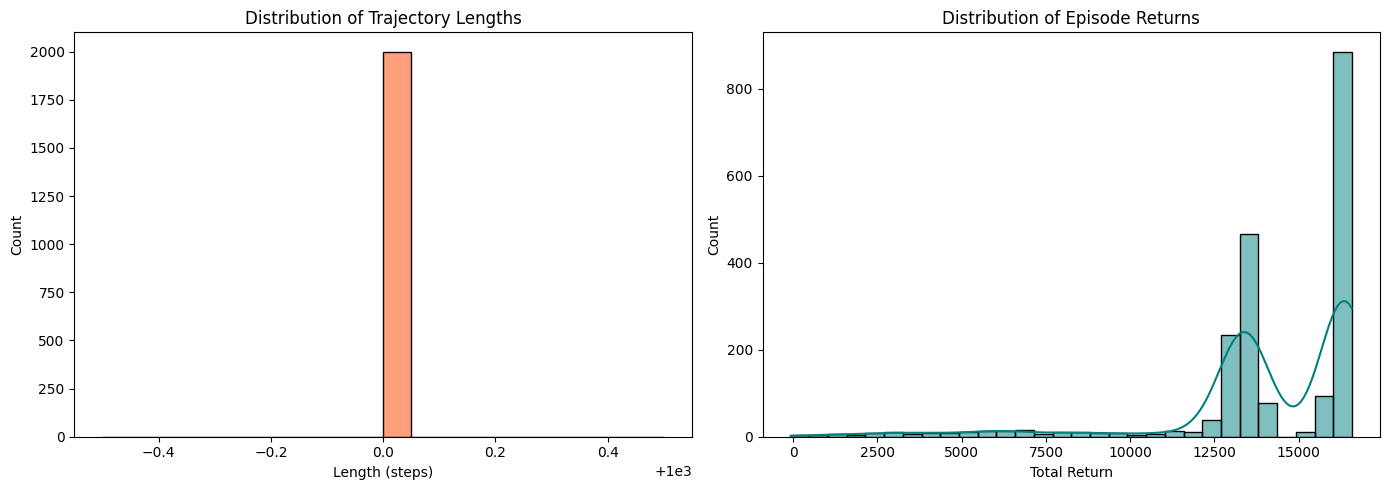

Average Trajectory Length: 1000.00
Average Episode Return: 14166.07


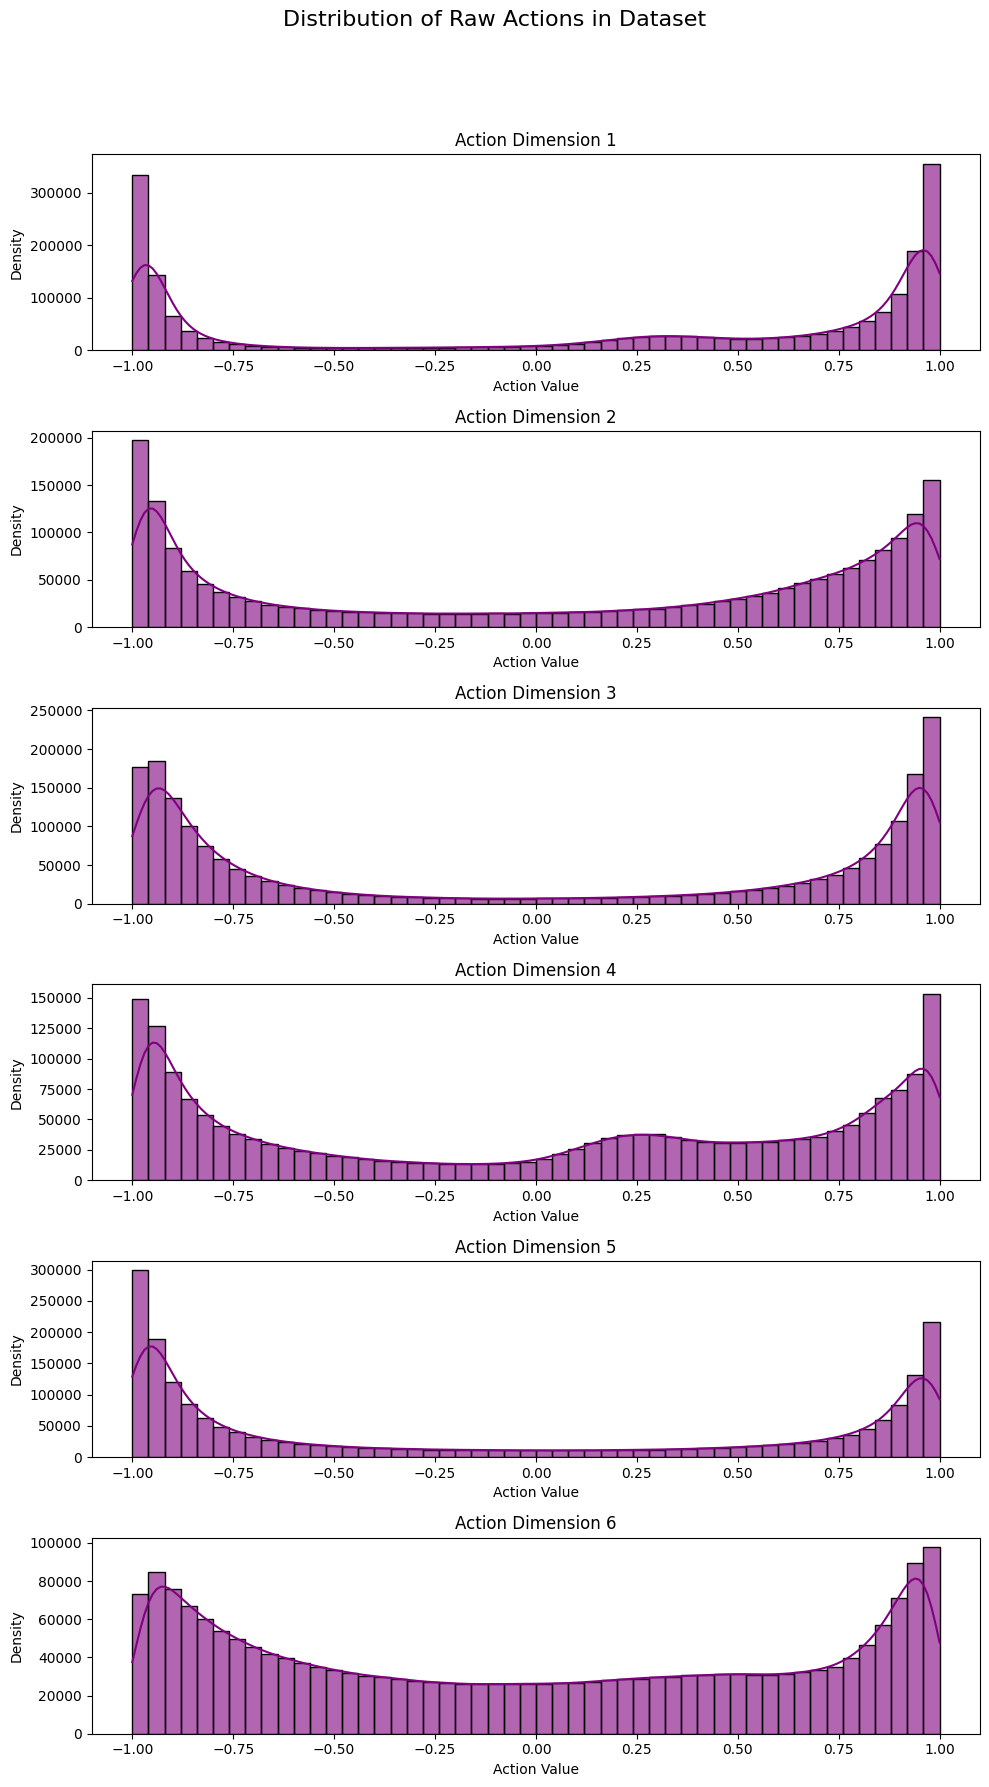

In [1]:
!pip install torch transformers gymnasium minari mujoco

import torch
import minari
import numpy as np
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class MinariTrajectoryDataset(Dataset):
    def __init__(self, dataset_names, context_window=64, rtg_scale=1000.0):
        self.context_window = context_window
        self.rtg_scale = rtg_scale
        self.trajectories = []

        all_states = [] #Collect all states for normalization

        for name in dataset_names:
            print(f"Loading {name}...")
            dataset = minari.load_dataset(name, download=True)

            for episode in dataset.iterate_episodes():
                states = episode.observations
                actions = episode.actions
                rewards = episode.rewards

                all_states.append(states)
                episode_length = len(rewards)

                #Calculate Return-to-Go (RTG) and scale it
                rtg = np.zeros_like(rewards, dtype=np.float32)
                for t in range(episode_length):
                    rtg[t] = np.sum(rewards[t:]) / self.rtg_scale #scaling applied

                self.trajectories.append({
                    'states': states, # Keep raw for now, normalize later
                    'actions': torch.tensor(actions, dtype=torch.float32),
                    'rtg': torch.tensor(rtg, dtype=torch.float32).unsqueeze(-1),
                    'length': episode_length
                })

        # Calculate State Normalization Statistics
        all_states_np = np.concatenate(all_states, axis=0)
        self.state_mean = torch.tensor(np.mean(all_states_np, axis=0), dtype=torch.float32)
        self.state_std = torch.tensor(np.std(all_states_np, axis=0) + 1e-6, dtype=torch.float32) # Add 1e-6 to prevent divide-by-zero

        # Apply Normalization to all trajectories
        for traj in self.trajectories:
            raw_states = torch.tensor(traj['states'], dtype=torch.float32)
            traj['states'] = (raw_states - self.state_mean) / self.state_std

    def __len__(self):
        return len(self.trajectories)

    def __getitem__(self, idx):
        traj = self.trajectories[idx]
        length = traj['length']

        #Sample a random sequence of length K
        if length > self.context_window:
            start_idx = np.random.randint(0, length - self.context_window)
        else:
            start_idx = 0

        end_idx = start_idx + self.context_window

        #Extract windowed data
        s = traj['states'][start_idx:end_idx]
        a = traj['actions'][start_idx:end_idx]
        r = traj['rtg'][start_idx:end_idx]
        t = torch.arange(start_idx, end_idx, dtype=torch.long)

        #Pad if sequence is shorter than context window
        if s.shape[0] < self.context_window:
            pad_len = self.context_window - s.shape[0]
            s = torch.cat([s, torch.zeros(pad_len, s.shape[1])])
            a = torch.cat([a, torch.zeros(pad_len, a.shape[1])])
            r = torch.cat([r, torch.zeros(pad_len, 1)])
            t = torch.cat([t, torch.zeros(pad_len, dtype=torch.long)])
            mask = torch.cat([torch.ones(s.shape[0] - pad_len), torch.zeros(pad_len)])
        else:
            mask = torch.ones(self.context_window)

        return s, a, r, t, mask

#Initialize Dataset and DataLoader with both datasets
dataset_names = ["mujoco/halfcheetah/expert-v0", "mujoco/halfcheetah/medium-v0"]
dataset = MinariTrajectoryDataset(dataset_names, context_window=64, rtg_scale=1000.0)

state_mean = dataset.state_mean.to(device)
state_std = dataset.state_std.to(device)
rtg_scale = 1000.0

dataloader = DataLoader(dataset, batch_size=64, shuffle=True)
print(f"Loaded {len(dataset)} trajectories.")

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Extract trajectory lengths and unscaled total returns
lengths = [traj['length'] for traj in dataset.trajectories]
# RTG is scaled by 1000 in the dataset, so we multiply by rtg_scale to get the actual return
actual_returns = [traj['rtg'][0].item() * rtg_scale for traj in dataset.trajectories]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Trajectory Lengths
sns.histplot(lengths, bins=20, kde=False, ax=axes[0], color='coral')
axes[0].set_title('Distribution of Trajectory Lengths')
axes[0].set_xlabel('Length (steps)')
axes[0].set_ylabel('Count')

# Plot Total Returns
sns.histplot(actual_returns, bins=30, kde=True, ax=axes[1], color='teal')
axes[1].set_title('Distribution of Episode Returns')
axes[1].set_xlabel('Total Return')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f"Average Trajectory Length: {np.mean(lengths):.2f}")
print(f"Average Episode Return: {np.mean(actual_returns):.2f}")

# Analyze raw actions from the dataset
all_actions_list = [traj['actions'].numpy() for traj in dataset.trajectories]
all_actions_np = np.concatenate(all_actions_list, axis=0)

num_action_dims = all_actions_np.shape[1]
fig, axes = plt.subplots(num_action_dims, 1, figsize=(10, 3 * num_action_dims))
fig.suptitle('Distribution of Raw Actions in Dataset', y=1.02, fontsize=16)

for i in range(num_action_dims):
    ax = axes[i] if num_action_dims > 1 else axes
    sns.histplot(all_actions_np[:, i], bins=50, kde=True, ax=ax, color='purple', alpha=0.6)
    ax.set_title(f'Action Dimension {i+1}')
    ax.set_xlabel('Action Value')
    ax.set_ylabel('Density')

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()